# 1D CNN for Viral Recombination Breakpoint Detection

This notebook implements a convolutional neural network approach for detecting recombination breakpoints at the nucleotide level. Unlike feature-based approaches (RDPML.ipynb, RDPML_PSNN.ipynb), this model works directly on raw sequence data using one-hot encoding.

**Approach:**
- **Input**: Triplet of aligned sequences (recombinant + 2 parents), one-hot encoded as a multi-channel 1D signal
- **Output**: Per-position probability of breakpoint occurrence
- **Models**:
  1. Multi-scale 1D CNN with parallel convolutional paths for breakpoint detection
  2. Autoencoder trained on non-recombinant sequences for anomaly-based detection

In [ ]:
# Core libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow/Keras
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, UpSampling1D,
    Dropout, BatchNormalization, Dense, Flatten,
    Concatenate, GlobalAveragePooling1D, Reshape,
    Add, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import backend as K

# Scikit-learn
from sklearn.metrics import (
    precision_recall_fscore_support, roc_auc_score,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

# BioPython for FASTA parsing
from Bio import SeqIO

# Progress tracking (tqdm.auto falls back to plain text bar if widgets unavailable)
from tqdm.auto import tqdm

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.18.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
# Configuration

# Data paths
DATA_ROOT = Path("dataRaw")
TRAIN_DIRS = ["XML-1", "XML-2", "XML-3", "XML-4", "XML-5"]
TEST_DIR = "UnseenTestSet"

# Sequence encoding
MAX_SEQ_LEN = 4000          # Pad/truncate all sequences to this length
NUCLEOTIDES = ['A', 'T', 'G', 'C', '-']
N_CHANNELS = len(NUCLEOTIDES)  # 5 (one-hot dimension per sequence)
N_INPUT_CHANNELS = 3 * N_CHANNELS  # 15 (triplet: recombinant + 2 parents)

# Label generation
BP_WINDOW = 10              # +/- bp around each breakpoint edge for labels
TOLERANCE = 200             # +/- bp tolerance for evaluation

# Training
BATCH_SIZE = 16
EPOCHS = 100
LR = 1e-4
VAL_SPLIT = 0.15

# Focal loss
FOCAL_ALPHA = 0.25
FOCAL_GAMMA = 2.0

print(f"Max sequence length: {MAX_SEQ_LEN}")
print(f"Input channels (triplet): {N_INPUT_CHANNELS}")
print(f"Training directories: {TRAIN_DIRS}")

Max sequence length: 4000
Input channels (triplet): 15
Training directories: ['XML-1', 'XML-2', 'XML-3', 'XML-4', 'XML-5']


## Data Parsing and Preprocessing

Each SANTA simulation produces:
1. **FASTA alignment** (`.fa`) — ~100 aligned sequences per file
2. **SimVSRealCompare CSV** — ground truth: `ActualRecomb` (sequence ID), `SimBPStart`, `SimBPEnd`
3. **RecombIdentifyStats CSV** — 3 rows per event with `ISeqs(A)` identifying triplet members

For each recombination event we extract a **triplet**: the recombinant sequence and two parent sequences, identified by matching the `ActualRecomb` ID against the `ISeqs(A)` column in the stats CSV.

### One-Hot Encoding

In [11]:
def one_hot_encode(sequence, max_length=MAX_SEQ_LEN):
    """One-hot encode a nucleotide sequence (A/T/G/C/gap) with padding.

    Args:
        sequence: Nucleotide string.
        max_length: Pad or truncate to this length.

    Returns:
        np.ndarray of shape (max_length, 5).
    """
    nuc_idx = {'A': 0, 'T': 1, 'G': 2, 'C': 3, '-': 4}
    encoded = np.zeros((max_length, N_CHANNELS), dtype=np.float32)
    for i, nuc in enumerate(sequence[:max_length].upper()):
        idx = nuc_idx.get(nuc, 4)  # Unknown nucleotides treated as gaps
        encoded[i, idx] = 1.0
    return encoded


def encode_triplet(seq_recomb, seq_parent1, seq_parent2):
    """Stack three one-hot encoded sequences into a single multi-channel input.

    Returns:
        np.ndarray of shape (max_length, 15).
    """
    return np.concatenate([
        one_hot_encode(seq_recomb),
        one_hot_encode(seq_parent1),
        one_hot_encode(seq_parent2)
    ], axis=1)


# Sanity check
test_enc = one_hot_encode("ATGC-N", max_length=6)
print(f"One-hot shape: {test_enc.shape}")
print(f"A=[1,0,0,0,0]: {test_enc[0].tolist()}")
print(f"T=[0,1,0,0,0]: {test_enc[1].tolist()}")
print(f"Gap=[-]:       {test_enc[4].tolist()}")
print(f"Unknown->gap:  {test_enc[5].tolist()}")

One-hot shape: (6, 5)
A=[1,0,0,0,0]: [1.0, 0.0, 0.0, 0.0, 0.0]
T=[0,1,0,0,0]: [0.0, 1.0, 0.0, 0.0, 0.0]
Gap=[-]:       [0.0, 0.0, 0.0, 0.0, 1.0]
Unknown->gap:  [0.0, 0.0, 0.0, 0.0, 1.0]


### Label Generation from Breakpoint Positions

Two labelling modes are supported:
- **Breakpoint-only** (primary): Only positions within a small window (+/-10 bp) around each breakpoint edge are labelled as positive. This trains the model to pinpoint exact breakpoint transitions.
- **Region**: All positions between `SimBPStart` and `SimBPEnd` are labelled positive. This captures the full recombinant region.

Circular genome wrapping (where `bp_start > bp_end`) is handled explicitly.

In [12]:
def generate_labels(bp_start, bp_end, seq_length=MAX_SEQ_LEN,
                    mode='breakpoint', window=BP_WINDOW):
    """Generate per-position binary labels from breakpoint coordinates.

    Args:
        bp_start: Breakpoint start position.
        bp_end: Breakpoint end position.
        seq_length: Length of the label vector.
        mode: 'breakpoint' marks only edges (+/- window), 'region' marks the
              entire recombinant region between breakpoints.
        window: Half-width of the window around each breakpoint edge.

    Returns:
        np.ndarray of shape (seq_length,) with binary labels.
    """
    labels = np.zeros(seq_length, dtype=np.float32)
    circular = bp_start > bp_end  # Circular genome wrapping

    if mode == 'region':
        if circular:
            labels[bp_start:] = 1.0
            labels[:bp_end + 1] = 1.0
        else:
            labels[bp_start:bp_end + 1] = 1.0
    else:  # breakpoint-only
        for bp in [bp_start, bp_end]:
            lo = max(0, bp - window)
            hi = min(seq_length, bp + window + 1)
            labels[lo:hi] = 1.0

    return labels


# Verify both modes
lbl_bp = generate_labels(500, 1500, mode='breakpoint')
lbl_rg = generate_labels(500, 1500, mode='region')
lbl_circ = generate_labels(3500, 200, mode='breakpoint')
print(f"Breakpoint-only positives: {int(lbl_bp.sum())}")
print(f"Region positives:          {int(lbl_rg.sum())}")
print(f"Circular breakpoint:       {int(lbl_circ.sum())}")

Breakpoint-only positives: 42
Region positives:          1001
Circular breakpoint:       42


### Parsing SANTA Simulation Output

For each `.fa` file, the parser:
1. Reads sequences from the FASTA alignment
2. Reads `SimVSRealCompare.csv` for ground truth breakpoints (`ActualRecomb`, `SimBPStart`, `SimBPEnd`)
3. Reads `RecombIdentifyStats.csv` to find the 3 hypothesis rows per event
4. Matches `ActualRecomb` to `ISeqs(A)` to identify which row is the recombinant; the other two rows provide parent sequence IDs
5. Extracts the triplet of sequences and generates labels

In [13]:
def parse_simulation(fasta_path):
    """Parse one SANTA simulation run (FASTA + associated CSVs).

    For each recombination event the function extracts the recombinant
    sequence and two parent sequences, one-hot encodes the triplet, and
    generates per-position labels.

    Args:
        fasta_path: Path to the .fa alignment file.

    Returns:
        List of dicts with keys 'input', 'labels_bp', 'labels_region', 'meta'.
    """
    fasta_path = Path(fasta_path)
    sim_csv = fasta_path.parent / f"{fasta_path.name}SimVSRealCompare.csv"
    stats_csv = fasta_path.parent / f"{fasta_path.name}RecombIdentifyStats.csv"

    if not sim_csv.exists() or not stats_csv.exists():
        return []

    # Load sequences
    try:
        seqs = {int(r.id): str(r.seq) for r in SeqIO.parse(fasta_path, 'fasta')}
    except Exception:
        return []

    # Load CSVs
    try:
        sim = pd.read_csv(sim_csv, skipinitialspace=True)
        stats = pd.read_csv(stats_csv, skipinitialspace=True)
    except Exception:
        return []

    results = []
    for _, row in sim.iterrows():
        event = row['RDPEvent']
        recomb_id = int(row['ActualRecomb'])
        bp_start = int(row['SimBPStart'])
        bp_end = int(row['SimBPEnd'])

        # Find the 3 hypothesis rows for this event
        ev_rows = stats[stats['Event'] == event]
        if len(ev_rows) != 3:
            continue

        # Identify parent sequences from non-recombinant hypothesis rows
        parent_ids = []
        for _, sr in ev_rows.iterrows():
            ids = [int(s.strip()) for s in str(sr['ISeqs(A)']).split('$')
                   if s.strip().isdigit()]
            if recomb_id in ids:
                continue  # Skip the recombinant hypothesis row
            if ids:
                parent_ids.append(ids[0])

        if len(parent_ids) < 2:
            continue

        # Check all sequences exist in the FASTA
        if not all(sid in seqs for sid in [recomb_id, parent_ids[0], parent_ids[1]]):
            continue

        triplet = encode_triplet(
            seqs[recomb_id], seqs[parent_ids[0]], seqs[parent_ids[1]]
        )

        results.append({
            'input': triplet,
            'labels_bp': generate_labels(bp_start, bp_end, mode='breakpoint'),
            'labels_region': generate_labels(bp_start, bp_end, mode='region'),
            'meta': {
                'file': fasta_path.name,
                'event': event,
                'recomb_id': recomb_id,
                'parent1_id': parent_ids[0],
                'parent2_id': parent_ids[1],
                'bp_start': bp_start,
                'bp_end': bp_end,
                'actual_len': len(seqs[recomb_id].rstrip('-')),
            },
        })

    return results


# Test on one file
sample_fa = sorted((DATA_ROOT / "XML-1").glob("*.fa"))[0]
sample_triplets = parse_simulation(sample_fa)
print(f"Parsed {len(sample_triplets)} triplets from {sample_fa.name}")
if sample_triplets:
    print(f"Input shape:  {sample_triplets[0]['input'].shape}")
    print(f"Labels shape: {sample_triplets[0]['labels_bp'].shape}")
    print(f"Metadata:     {sample_triplets[0]['meta']}")

Parsed 0 triplets from alignment_XML1-2500-0.005-12E-5-100-1.fa


In [14]:
def load_dataset(directories, label_mode='breakpoint', max_files=None):
    """Load and aggregate triplet data from multiple simulation directories.

    Args:
        directories: List of subdirectory names under DATA_ROOT.
        label_mode: 'breakpoint' or 'region'.
        max_files: Optional per-directory file limit (for quick testing).

    Returns:
        X  -- np.ndarray (n, MAX_SEQ_LEN, 15)
        y  -- np.ndarray (n, MAX_SEQ_LEN)
        meta -- list of metadata dicts
    """
    inputs, labels, meta = [], [], []

    for d in directories:
        fa_files = sorted((DATA_ROOT / d).glob("*.fa"))
        if max_files:
            fa_files = fa_files[:max_files]

        print(f"\nProcessing {d}: {len(fa_files)} files")
        for fa in tqdm(fa_files, desc=d):
            for t in parse_simulation(fa):
                inputs.append(t['input'])
                key = 'labels_bp' if label_mode == 'breakpoint' else 'labels_region'
                labels.append(t[key])
                meta.append(t['meta'])

    X = np.array(inputs, dtype=np.float32)
    y = np.array(labels, dtype=np.float32)

    pos_frac = np.sum(y) / y.size * 100
    print(f"\n{'='*60}")
    print(f"Loaded {X.shape[0]} samples")
    print(f"X shape: {X.shape}  |  y shape: {y.shape}")
    print(f"Positive labels: {np.sum(y):.0f} / {y.size} ({pos_frac:.3f}%)")
    print(f"{'='*60}")

    return X, y, meta

In [27]:
# Load training data
# Set max_files=10 for a quick test run; set to None for the full dataset
X_all, y_all, meta_all = load_dataset(
    TRAIN_DIRS,
    label_mode='breakpoint',
    max_files=100,
)


Processing XML-1: 100 files


XML-1: 100%|██████████| 100/100 [00:03<00:00, 31.64it/s]



Processing XML-2: 100 files


XML-2: 100%|██████████| 100/100 [00:06<00:00, 14.34it/s]



Processing XML-3: 100 files


...


Processing XML-4: 100 files


XML-4: 100%|██████████| 100/100 [00:08<00:00, 11.68it/s]



Processing XML-5: 100 files


XML-5: 100%|██████████| 100/100 [00:06<00:00, 16.27it/s]



Loaded 220 samples
X shape: (220, 4000, 15)  |  y shape: (220, 4000)
Positive labels: 4987 / 880000 (0.567%)


In [28]:
# Train / validation split
split = int(len(X_all) * (1 - VAL_SPLIT))
indices = np.random.permutation(len(X_all))

X_train = X_all[indices[:split]]
y_train = y_all[indices[:split]]
meta_train = [meta_all[i] for i in indices[:split]]

X_val = X_all[indices[split:]]
y_val = y_all[indices[split:]]
meta_val = [meta_all[i] for i in indices[split:]]

pos_weight = (y_train.size - np.sum(y_train)) / max(np.sum(y_train), 1)

print(f"Training:   {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Positive class weight: {pos_weight:.1f}")

Training:   187 samples
Validation: 33 samples
Positive class weight: 175.1


## Loss Functions and Evaluation Metrics

Breakpoint positions are extremely rare (<1% of all positions), so standard binary cross-entropy would be dominated by the negative class. We use **focal loss** to focus training on the hard, rare positive examples.

Evaluation uses a **tolerance-based** metric: a predicted breakpoint within +/-200 bp of a true breakpoint counts as correct.

In [29]:
def focal_loss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA):
    """Focal loss for extreme class imbalance.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Down-weights easy negatives so the model focuses on learning the
    rare breakpoint signal.
    """
    def loss(y_true, y_pred):
        eps = K.epsilon()
        y_pred = K.clip(y_pred, eps, 1.0 - eps)

        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_weight = K.pow(1 - p_t, gamma)

        bce = -(y_true * K.log(y_pred) + (1 - y_true) * K.log(1 - y_pred))
        return K.mean(alpha_t * focal_weight * bce)

    return loss

In [30]:
def tolerance_precision_recall(y_true, y_pred, tolerance=TOLERANCE, threshold=0.5):
    """Precision / recall / F1 with a tolerance window around true breakpoints.

    A prediction is a true positive if any true breakpoint position falls
    within +/- tolerance of the predicted position.

    Args:
        y_true: 1-D binary label array.
        y_pred: 1-D prediction array (probabilities).
        tolerance: Allowed distance in bp.
        threshold: Binarisation threshold.

    Returns:
        (precision, recall, f1)
    """
    pred_pos = np.where(y_pred > threshold)[0]
    true_pos = np.where(y_true == 1)[0]

    if len(true_pos) == 0 or len(pred_pos) == 0:
        return 0.0, 0.0, 0.0

    # True positives: predicted positions near a true breakpoint
    tp = sum(1 for p in pred_pos if np.min(np.abs(true_pos - p)) <= tolerance)
    # Unique true breakpoints detected
    detected = {true_pos[np.argmin(np.abs(true_pos - p))] for p in pred_pos
                if np.min(np.abs(true_pos - p)) <= tolerance}

    precision = tp / len(pred_pos)
    recall = len(detected) / len(set(true_pos))
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1


def evaluate_tolerance(y_true_batch, y_pred_batch, tolerance=TOLERANCE, threshold=0.5):
    """Aggregate tolerance-based metrics across a batch of samples."""
    metrics = [tolerance_precision_recall(yt, yp, tolerance, threshold)
               for yt, yp in zip(y_true_batch, y_pred_batch)]
    p, r, f = zip(*metrics)
    return np.mean(p), np.mean(r), np.mean(f)

## 1D CNN Model

**Multi-scale architecture** with parallel convolutional paths at kernel sizes 3, 7, 15, and 31. This captures both short-range nucleotide changes and long-range compositional shifts characteristic of recombination breakpoints.

All convolutions use `padding='same'` so the output retains the input sequence length, enabling per-position prediction.

In [31]:
def build_cnn(input_shape=(MAX_SEQ_LEN, N_INPUT_CHANNELS),
              filter_sizes=(3, 7, 15, 31),
              n_filters=64,
              dropout=0.3):
    """Multi-scale 1D CNN for per-position breakpoint detection.

    Architecture:
        1. Shared initial convolution
        2. Parallel branches with different kernel sizes (multi-scale)
        3. Concatenation and integration layers
        4. Position-wise classification head (sigmoid output)

    Args:
        input_shape: (sequence_length, channels).
        filter_sizes: Kernel sizes for parallel convolutional paths.
        n_filters: Filters per path.
        dropout: Dropout rate.

    Returns:
        Keras Model with output shape (batch, sequence_length).
    """
    inputs = Input(shape=input_shape, name='triplet_input')

    # Shared initial convolution
    x = Conv1D(64, 3, padding='same', activation='relu', name='conv_shared')(inputs)
    x = BatchNormalization(name='bn_shared')(x)

    # Multi-scale parallel branches
    branches = []
    for ks in filter_sizes:
        b = Conv1D(n_filters, ks, padding='same', activation='relu',
                   name=f'conv_k{ks}')(x)
        b = BatchNormalization(name=f'bn_k{ks}')(b)
        b = Dropout(dropout, name=f'drop_k{ks}')(b)
        branches.append(b)

    merged = Concatenate(name='merge_scales')(branches)

    # Integration layers
    x = Conv1D(128, 7, padding='same', activation='relu', name='conv_int1')(merged)
    x = BatchNormalization(name='bn_int1')(x)
    x = Dropout(dropout, name='drop_int1')(x)

    x = Conv1D(64, 5, padding='same', activation='relu', name='conv_int2')(x)
    x = BatchNormalization(name='bn_int2')(x)
    x = Dropout(dropout, name='drop_int2')(x)

    # Position-wise classification head
    x = Conv1D(32, 1, activation='relu', name='conv_pw1')(x)
    x = Dropout(dropout, name='drop_pw')(x)
    x = Conv1D(1, 1, activation='sigmoid', name='conv_out')(x)

    outputs = Reshape((MAX_SEQ_LEN,), name='output')(x)

    model = Model(inputs, outputs, name='MultiScaleCNN_Breakpoint')
    return model


cnn = build_cnn()
cnn.compile(
    optimizer=AdamW(learning_rate=LR, weight_decay=1e-5),
    loss=focal_loss(),
    metrics=['binary_accuracy'],
)
cnn.summary()

Model: "MultiScaleCNN_Breakpoint"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ triplet_input       │ (None, 4000, 15)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_shared         │ (None, 4000, 64)  │      2,944 │ triplet_input[0]… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_shared           │ (None, 4000, 64)  │        256 │ conv_shared[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k3 (Conv1D)    │ (None, 4000, 64)  │     12,352 │ bn_shared[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k7 (Conv1D)    │ (None, 4000, 64)  │     28,736 │ bn_shared[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k15 (Conv1D)   │ (None, 4000, 64)  │     61,504 │ bn_shared[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k31 (Conv1D)   │ (None, 4000, 64)  │    127,040 │ bn_shared[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_k3               │ (None, 4000, 64)  │        256 │ conv_k3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_k7               │ (None, 4000, 64)  │        256 │ conv_k7[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_k15              │ (None, 4000, 64)  │        256 │ conv_k15[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_k31              │ (None, 4000, 64)  │        256 │ conv_k31[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_k3 (Dropout)   │ (None, 4000, 64)  │          0 │ bn_k3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_k7 (Dropout)   │ (None, 4000, 64)  │          0 │ bn_k7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_k15 (Dropout)  │ (None, 4000, 64)  │          0 │ bn_k15[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_k31 (Dropout)  │ (None, 4000, 64)  │          0 │ bn_k31[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge_scales        │ (None, 4000, 256) │          0 │ drop_k3[0][0],    │
│ (Concatenate)       │                   │            │ drop_k7[0][0],    │
│                     │                   │            │ drop_k15[0][0],   │
│                     │                   │            │ drop_k31[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_int1 (Conv1D)  │ (None, 4000, 128) │    229,504 │ merge_scales[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_int1             │ (None, 4000, 128) │        512 │ conv_int1[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_int1 (Dropout) │ (None, 4000, 128) │          0 │ bn_int1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 507,265 (1.94 MB)

 Trainable params: 506,241 (1.93 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [32]:
from tensorflow.keras.utils import plot_model

plot_model(
    cnn,
    to_file='figures/cnn_breakpoint_architecture.png',
    show_shapes=True,
    show_layer_names=True,
)
print("Architecture diagram saved to figures/cnn_breakpoint_architecture.png")

Architecture diagram saved to figures/cnn_breakpoint_architecture.png


### CNN Training

In [33]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath='models_test/cnn_breakpoint_best.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1,
    ),
]

print("Callbacks:", [cb.__class__.__name__ for cb in callbacks])

Callbacks: ['EarlyStopping', 'ReduceLROnPlateau', 'ModelCheckpoint']


In [34]:
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

print("\nTraining complete.")

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - binary_accuracy: 0.4858 - loss: 0.3588   
Epoch 1: val_loss improved from inf to 0.12294, saving model to models_test/cnn_breakpoint_best.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - binary_accuracy: 0.4870 - loss: 0.3572 - val_binary_accuracy: 0.7553 - val_loss: 0.1229 - learning_rate: 1.0000e-04
Epoch 2/100
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - binary_accuracy: 0.5599 - loss: 0.2732
Epoch 2: val_loss did not improve from 0.12294
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - binary_accuracy: 0.5630 - loss: 0.2702 - val_binary_accuracy: 0.5035 - val_loss: 0.1294 - learning_rate: 1.0000e-04
Epoch 3/100
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - binary_accuracy: 0.6458 - loss: 0.1998
Epoch 3: val_loss did not improve from 0.12294
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - binary_accuracy: 0.6489 - loss: 0.1975 - val_binary_accuracy: 0.5809 - val_loss: 0.1255 - learning_rate: 1.0000e-04
Epoch 4/100
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

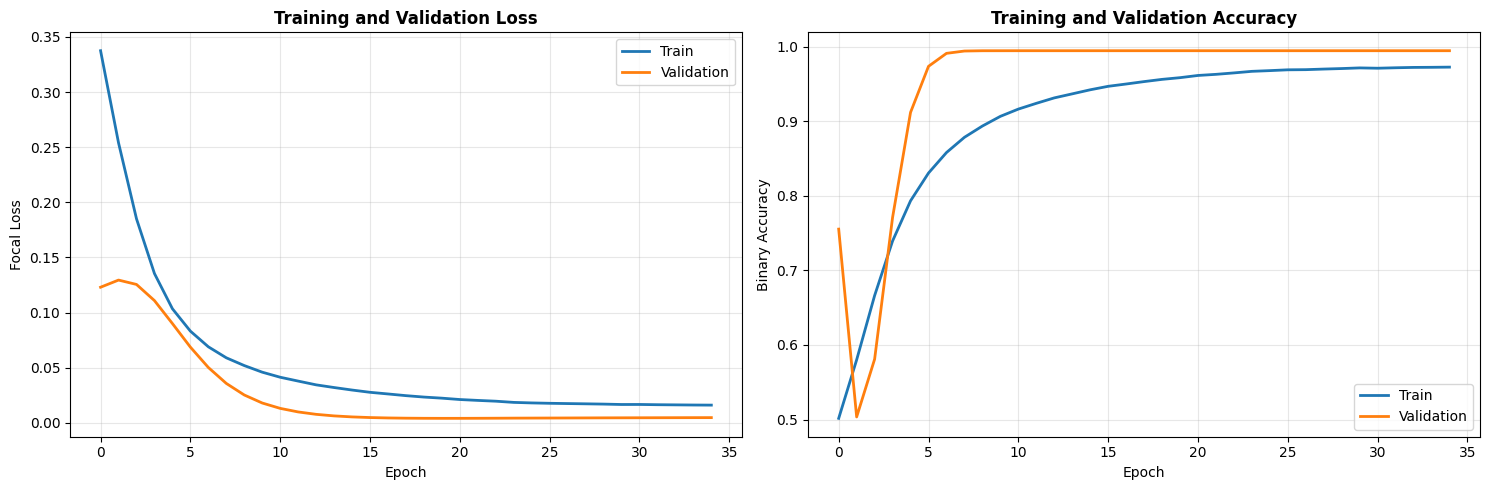

In [35]:
def plot_history(history):
    """Plot training loss and accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Loss
    axes[0].plot(history.history['loss'], label='Train', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Focal Loss')
    axes[0].set_title('Training and Validation Loss', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    if 'binary_accuracy' in history.history:
        axes[1].plot(history.history['binary_accuracy'], label='Train', linewidth=2)
        axes[1].plot(history.history['val_binary_accuracy'], label='Validation', linewidth=2)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Binary Accuracy')
        axes[1].set_title('Training and Validation Accuracy', fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('figures/cnn_training_history.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_history(history)

In [36]:
cnn.save('models_test/cnn_breakpoint_final.keras')
print("Model saved to models_test/cnn_breakpoint_final.keras")

Model saved to models_test/cnn_breakpoint_final.keras


## Autoencoder for Anomaly Detection

The autoencoder is trained **only on non-recombinant (parent) sequences**. The intuition is that breakpoint regions in recombinant sequences will be poorly reconstructed, producing high reconstruction error that can serve as a complementary anomaly signal.

In [37]:
def build_autoencoder(input_shape=(MAX_SEQ_LEN, N_INPUT_CHANNELS),
                      latent_dim=64, dropout=0.2):
    """Convolutional autoencoder for sequence reconstruction.

    Encoder downsamples via strided convolutions; decoder upsamples back.
    Trained on non-recombinant sequences so breakpoint regions produce
    higher reconstruction error.

    Args:
        input_shape: (sequence_length, channels).
        latent_dim: Dimensionality of the bottleneck.
        dropout: Dropout rate.

    Returns:
        (encoder, decoder, autoencoder) Keras Models.
    """
    # Encoder
    enc_in = Input(shape=input_shape, name='enc_input')

    x = Conv1D(64, 7, strides=2, padding='same', activation='relu')(enc_in)
    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)

    x = Conv1D(128, 5, strides=2, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)

    x = Conv1D(256, 3, strides=2, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    x = GlobalAveragePooling1D()(x)
    latent = Dense(latent_dim, activation='relu', name='latent')(x)

    encoder = Model(enc_in, latent, name='Encoder')

    # Decoder
    dec_in = Input(shape=(latent_dim,), name='dec_input')

    x = Dense(500 * 256, activation='relu')(dec_in)  # 4000 / 8 = 500
    x = Reshape((500, 256))(x)

    x = Conv1D(256, 3, padding='same', activation='relu')(x)
    x = UpSampling1D(2)(x)   # 500 -> 1000
    x = BatchNormalization()(x)

    x = Conv1D(128, 5, padding='same', activation='relu')(x)
    x = UpSampling1D(2)(x)   # 1000 -> 2000
    x = BatchNormalization()(x)

    x = Conv1D(64, 7, padding='same', activation='relu')(x)
    x = UpSampling1D(2)(x)   # 2000 -> 4000
    x = BatchNormalization()(x)

    dec_out = Conv1D(N_INPUT_CHANNELS, 3, padding='same',
                     activation='sigmoid', name='reconstruction')(x)

    decoder = Model(dec_in, dec_out, name='Decoder')

    # Full autoencoder
    ae_out = decoder(encoder(enc_in))
    autoencoder = Model(enc_in, ae_out, name='Autoencoder')

    return encoder, decoder, autoencoder


encoder, decoder, autoencoder = build_autoencoder()
autoencoder.compile(optimizer=Adam(learning_rate=LR), loss='mse')
autoencoder.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ enc_input (InputLayer)          │ (None, 4000, 15)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 64)             │       164,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 4000, 15)       │     8,742,927 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,907,599 (33.98 MB)

 Trainable params: 8,905,807 (33.97 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
def load_parent_sequences(directories, max_files=None):
    """Load non-recombinant sequences for autoencoder training.

    For each FASTA file, all sequences not listed as ActualRecomb in
    any event are treated as non-recombinant. Each parent sequence is
    replicated across the 3 triplet channels for architecture compatibility.

    Returns:
        np.ndarray of shape (n, MAX_SEQ_LEN, N_INPUT_CHANNELS).
    """
    parent_seqs = []

    for d in directories:
        fa_files = sorted((DATA_ROOT / d).glob("*.fa"))
        if max_files:
            fa_files = fa_files[:max_files]

        print(f"\nCollecting parents from {d}: {len(fa_files)} files")
        for fa in tqdm(fa_files, desc=d):
            sim_csv = fa.parent / f"{fa.name}SimVSRealCompare.csv"
            if not sim_csv.exists():
                continue

            try:
                seqs = {int(r.id): str(r.seq) for r in SeqIO.parse(fa, 'fasta')}
                sim = pd.read_csv(sim_csv, skipinitialspace=True)
            except Exception:
                continue

            recomb_ids = set(sim['ActualRecomb'].astype(int).tolist())
            parent_ids = [sid for sid in seqs if sid not in recomb_ids]

            # Sample up to 10 parents per file to keep dataset manageable
            for pid in parent_ids[:10]:
                enc = one_hot_encode(seqs[pid])
                # Replicate across triplet channels
                triplet = np.concatenate([enc, enc, enc], axis=1)
                parent_seqs.append(triplet)

    X = np.array(parent_seqs, dtype=np.float32)
    print(f"\nLoaded {X.shape[0]} parent sequences, shape: {X.shape}")
    return X


X_parents = load_parent_sequences(TRAIN_DIRS, max_files=None)

XML-1: 100%|██████████| 1215/1215 [00:46<00:00, 25.88it/s]


XML-2: 100%|██████████| 1110/1110 [01:12<00:00, 15.22it/s]


XML-3: 100%|██████████| 718/718 [00:37<00:00, 18.99it/s]


XML-4:  76%|███████▌  | 821/1080 [01:20<00:25, 10.10it/s]

In [ ]:
# Train autoencoder on parent (non-recombinant) sequences
ae_callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
]

ae_history = autoencoder.fit(
    X_parents, X_parents,  # Reconstruct input
    validation_split=0.15,
    batch_size=BATCH_SIZE,
    epochs=50,
    callbacks=ae_callbacks,
    verbose=1,
)

print("\nAutoencoder training complete.")

### Reconstruction Error Visualisation

When the autoencoder (trained only on non-recombinant data) is applied to recombinant sequences, breakpoint regions should show elevated reconstruction error because the model has never seen such compositional transitions.

In [ ]:
def plot_reconstruction_error(sample_idx, X_data, y_labels, meta_list):
    """Visualise per-position reconstruction error alongside true breakpoints."""
    sample = X_data[sample_idx:sample_idx + 1]
    reconstruction = autoencoder.predict(sample, verbose=0)
    mse_per_pos = np.mean((sample[0] - reconstruction[0]) ** 2, axis=1)

    m = meta_list[sample_idx]
    L = m['actual_len']

    fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

    # Reconstruction error
    axes[0].plot(range(L), mse_per_pos[:L], color='purple', linewidth=1)
    axes[0].set_ylabel('Reconstruction MSE')
    axes[0].set_title(
        f'Autoencoder Reconstruction Error \u2014 {m["file"]} (Event {m["event"]})',
        fontweight='bold'
    )
    axes[0].grid(True, alpha=0.3)

    # Mark true breakpoints
    for bp in [m['bp_start'], m['bp_end']]:
        if bp < L:
            axes[0].axvline(bp, color='red', linestyle='--', alpha=0.7, label='True BP')

    # Deduplicate legend
    handles, lbls = axes[0].get_legend_handles_labels()
    by_label = dict(zip(lbls, handles))
    axes[0].legend(by_label.values(), by_label.keys())

    # Ground truth labels
    axes[1].fill_between(range(L), 0, y_labels[sample_idx][:L],
                         color='green', alpha=0.5, label='Breakpoint region')
    axes[1].set_xlabel('Genomic Position (bp)')
    axes[1].set_ylabel('Label')
    axes[1].set_ylim(-0.1, 1.1)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


# Plot for first few validation samples
for i in range(min(3, len(X_val))):
    fig = plot_reconstruction_error(i, X_val, y_val, meta_val)
    fig.savefig(f'figures/ae_recon_error_{i}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Breakpoint Prediction Evaluation

Evaluate the CNN model using:
1. **Tolerance-based metrics**: Precision/Recall/F1 with +/-200 bp tolerance
2. **Per-position ROC and Precision-Recall curves**
3. **Visual inspection** of predictions on individual sequences with true breakpoints marked

In [ ]:
# Generate predictions on validation set
y_val_pred = cnn.predict(X_val, batch_size=BATCH_SIZE, verbose=1)

print(f"Prediction shape: {y_val_pred.shape}")
print(f"Range: [{y_val_pred.min():.4f}, {y_val_pred.max():.4f}]")

In [ ]:
# Evaluate at multiple thresholds to find the best operating point
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
results = []

print(f"Tolerance-based evaluation (+/-{TOLERANCE} bp)")
print("=" * 60)

for thr in thresholds:
    p, r, f = evaluate_tolerance(y_val, y_val_pred, TOLERANCE, thr)
    results.append({'threshold': thr, 'precision': p, 'recall': r, 'f1': f})
    print(f"  threshold={thr:.1f}  P={p:.3f}  R={r:.3f}  F1={f:.3f}")

results_df = pd.DataFrame(results)
best_idx = results_df['f1'].idxmax()
best_thr = results_df.loc[best_idx, 'threshold']
print(f"\nBest threshold: {best_thr} (F1={results_df.loc[best_idx, 'f1']:.3f})")

### Breakpoint Prediction Visualisation

In [ ]:
def plot_breakpoint_prediction(idx, X, y_true, y_pred, meta, threshold=0.5):
    """Visualise per-position breakpoint prediction for a single sample.

    Top panel: predicted probability with threshold line and true breakpoint markers.
    Bottom panel: ground truth label mask.
    """
    m = meta[idx]
    L = m['actual_len']
    positions = np.arange(L)

    yt = y_true[idx][:L]
    yp = y_pred[idx][:L]

    fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

    # Prediction curve
    axes[0].plot(positions, yp, color='blue', linewidth=1.5, label='Predicted probability')
    axes[0].axhline(threshold, color='red', linestyle='--', linewidth=1,
                    label=f'Threshold ({threshold})')
    axes[0].fill_between(positions, 0, yp, alpha=0.2, color='blue')

    # Mark true breakpoints
    for bp in [m['bp_start'], m['bp_end']]:
        if bp < L:
            axes[0].axvline(bp, color='green', linewidth=2, alpha=0.7, label='True BP')

    axes[0].set_ylabel('Probability')
    axes[0].set_title(
        f'Breakpoint Prediction \u2014 {m["file"]} (Event {m["event"]})',
        fontweight='bold'
    )
    # Deduplicate legend entries
    handles, lbls = axes[0].get_legend_handles_labels()
    by_label = dict(zip(lbls, handles))
    axes[0].legend(by_label.values(), by_label.keys(), loc='upper right')
    axes[0].set_ylim(-0.05, 1.05)
    axes[0].grid(True, alpha=0.3)

    # Ground truth
    axes[1].fill_between(positions, 0, yt, color='green', alpha=0.5,
                         label='True breakpoint region')
    axes[1].set_xlabel('Genomic Position (bp)')
    axes[1].set_ylabel('Label')
    axes[1].set_ylim(-0.1, 1.1)
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)

    info = (f"Recombinant: {m['recomb_id']}, "
            f"Parents: {m['parent1_id']}, {m['parent2_id']}  |  "
            f"True BP: {m['bp_start']}-{m['bp_end']}")
    fig.text(0.5, 0.01, info, ha='center', fontsize=10, style='italic')

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    return fig


# Plot example predictions
for i in range(min(5, len(X_val))):
    fig = plot_breakpoint_prediction(i, X_val, y_val, y_val_pred, meta_val,
                                    threshold=best_thr)
    fig.savefig(f'figures/bp_prediction_val_{i}.png', dpi=150, bbox_inches='tight')
    plt.show()

### ROC and Precision-Recall Curves

In [ ]:
def plot_roc_and_pr(y_true_flat, y_pred_flat):
    """Plot ROC and Precision-Recall curves for per-position predictions."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ROC
    fpr, tpr, _ = roc_curve(y_true_flat, y_pred_flat)
    roc_auc_val = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc_val:.3f})')
    axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Precision-Recall
    prec, rec, _ = precision_recall_curve(y_true_flat, y_pred_flat)
    ap = average_precision_score(y_true_flat, y_pred_flat)
    axes[1].plot(rec, prec, 'g-', linewidth=2, label=f'PR (AP = {ap:.3f})')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('figures/cnn_roc_pr_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_roc_and_pr(y_val.flatten(), y_val_pred.flatten())

### Per-Sample Performance Distribution

In [ ]:
# Per-sample metric distributions
sample_metrics = []
for i in range(len(y_val)):
    p, r, f = tolerance_precision_recall(y_val[i], y_val_pred[i],
                                         TOLERANCE, best_thr)
    sample_metrics.append({'precision': p, 'recall': r, 'f1': f})

metrics_df = pd.DataFrame(sample_metrics)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, colour in zip(axes, ['precision', 'recall', 'f1'],
                            ['steelblue', 'seagreen', 'darkorange']):
    ax.hist(metrics_df[col], bins=20, color=colour, alpha=0.7, edgecolor='black')
    mean_val = metrics_df[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2,
               label=f'Mean: {mean_val:.3f}')
    ax.set_xlabel(col.title())
    ax.set_ylabel('Count')
    ax.set_title(f'{col.title()} Distribution', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('figures/cnn_metric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPer-sample performance summary:")
print(metrics_df.describe().round(3))

## Unseen Test Set Evaluation

In [ ]:
# Load and evaluate on unseen test set
X_test, y_test, meta_test = load_dataset(
    [TEST_DIR],
    label_mode='breakpoint',
)

y_test_pred = cnn.predict(X_test, batch_size=BATCH_SIZE, verbose=1)

p, r, f = evaluate_tolerance(y_test, y_test_pred, TOLERANCE, best_thr)

print("\n" + "=" * 60)
print("UNSEEN TEST SET PERFORMANCE")
print("=" * 60)
print(f"Precision: {p:.3f}")
print(f"Recall:    {r:.3f}")
print(f"F1 Score:  {f:.3f}")
print(f"Threshold: {best_thr}  |  Tolerance: +/-{TOLERANCE} bp")
print("=" * 60)

In [ ]:
# Visualise test set predictions
for i in range(min(5, len(X_test))):
    fig = plot_breakpoint_prediction(i, X_test, y_test, y_test_pred,
                                    meta_test, threshold=best_thr)
    fig.savefig(f'figures/bp_prediction_test_{i}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Analysis

Investigate model performance across different conditions:
- Circular vs linear genome breakpoints
- Performance by genome length
- Gradient-based saliency maps for interpretability

In [ ]:
# Circular vs linear genome breakpoints
circular_mask = np.array([m['bp_start'] > m['bp_end'] for m in meta_val])

if circular_mask.any():
    circ_metrics = metrics_df[circular_mask]
    lin_metrics = metrics_df[~circular_mask]

    print("Performance comparison: Circular vs Linear genomes")
    print("\nCircular:")
    print(circ_metrics[['precision', 'recall', 'f1']].describe().round(3))
    print("\nLinear:")
    print(lin_metrics[['precision', 'recall', 'f1']].describe().round(3))
else:
    print("No circular genome breakpoints found in validation set.")

In [ ]:
# Performance by genome length
metrics_df['actual_len'] = [m['actual_len'] for m in meta_val]

bins = [0, 2500, 3000, 3500, 4500]
bin_labels = ['<2500', '2500-3000', '3000-3500', '3500+']
metrics_df['len_bin'] = pd.cut(metrics_df['actual_len'], bins=bins, labels=bin_labels)

length_perf = metrics_df.groupby('len_bin', observed=True)[['precision', 'recall', 'f1']].agg(
    ['mean', 'std', 'count']
)
print("Performance by genome length:")
print(length_perf.round(3))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
summary = metrics_df.groupby('len_bin', observed=True)['f1'].agg(['mean', 'std'])
summary.plot(y='mean', yerr='std', kind='bar', ax=ax, capsize=5,
             color='steelblue', edgecolor='black', legend=False)
ax.set_xlabel('Genome Length Bin')
ax.set_ylabel('Mean F1 Score')
ax.set_title('Model Performance by Genome Length', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/performance_by_length.png', dpi=150, bbox_inches='tight')
plt.show()

### Saliency Map (Input Attribution)

In [ ]:
@tf.function
def compute_saliency(model, x):
    """Compute gradient-based saliency map for input attribution."""
    with tf.GradientTape() as tape:
        tape.watch(x)
        pred = model(x)
        target = tf.reduce_mean(pred)
    return tape.gradient(target, x)


sample_idx = 0
sample_in = tf.convert_to_tensor(X_val[sample_idx:sample_idx + 1], dtype=tf.float32)
saliency = compute_saliency(cnn, sample_in)
saliency_per_pos = np.abs(saliency.numpy()[0]).sum(axis=1)

m = meta_val[sample_idx]
L = m['actual_len']

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(range(L), saliency_per_pos[:L], color='purple', linewidth=1)
for bp in [m['bp_start'], m['bp_end']]:
    if bp < L:
        axes[0].axvline(bp, color='red', linestyle='--', alpha=0.7)
axes[0].set_ylabel('|Gradient| (summed over channels)')
axes[0].set_title('Saliency Map \u2014 Feature Importance per Position', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(L), y_val_pred[sample_idx][:L], 'b-', label='Prediction', linewidth=1.5)
axes[1].fill_between(range(L), 0, y_val[sample_idx][:L],
                     color='green', alpha=0.3, label='Ground Truth')
axes[1].set_xlabel('Genomic Position (bp)')
axes[1].set_ylabel('Probability')
axes[1].set_title('Prediction vs Ground Truth', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/saliency_analysis.png', dpi=150, bbox_inches='tight')
plt.show()